In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [217]:
df = pd.read_csv("../data/cloud_server_cost_dataset.csv")

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   cpu_usage                  200000 non-null  float64
 1   memory_usage               200000 non-null  float64
 2   network_traffic            200000 non-null  float64
 3   execution_time             200000 non-null  float64
 4   num_executed_instructions  200000 non-null  int64  
 5   task_priority              200000 non-null  int64  
 6   energy_efficiency          200000 non-null  float64
 7   cloud_operational_cost     200000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 12.2 MB


In [219]:
df.describe()

,cpu_usage,memory_usage,network_traffic,execution_time,num_executed_instructions,task_priority,energy_efficiency,cloud_operational_cost
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000
mean,46.730300,42.994720,173.885547,2.520438,442599.98468,2.948465,0.744417,9.983464
std,20.638327,15.917494,186.455839,2.070126,218936.06267,1.203564,0.092578,5.454465
min,0.000000,0.000000,10.000000,0.100000,10000.00000,1.000000,0.500000,0.100000
25%,33.980000,35.050000,57.091125,1.104075,303180.75000,2.000000,0.683500,6.543075
50%,46.700000,44.790000,110.424000,1.924650,414918.50000,3.000000,0.751300,9.311350
75%,60.980000,53.520000,214.327375,3.256525,565976.50000,4.000000,0.810700,13.215125
max,100.000000,100.000000,1000.000000,10.000000,1000000.00000,5.000000,1.000000,29.285000


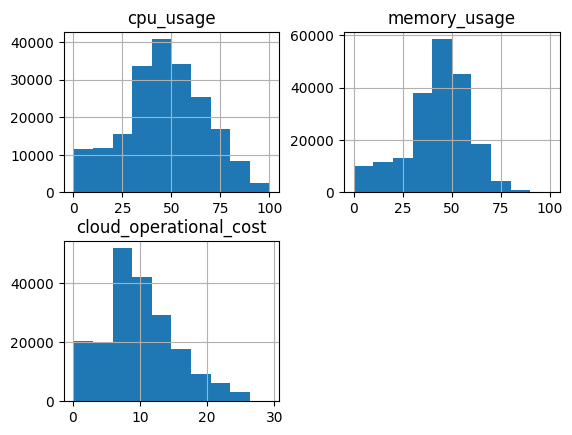

In [220]:
viz = df[['cpu_usage','memory_usage','cloud_operational_cost']]
viz.hist()
plt.show()

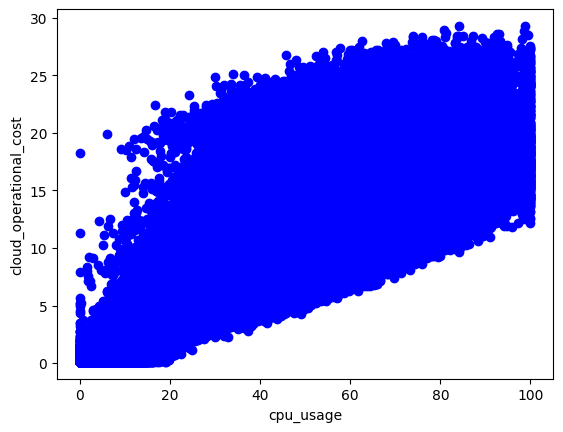

In [221]:
plt.scatter(df.cpu_usage,df.cloud_operational_cost,  color='blue')
plt.xlabel("cpu_usage")
plt.ylabel("cloud_operational_cost")
plt.show()

In [222]:
print(df["memory_usage"].isnull().sum())
print(df["cloud_operational_cost"].isnull().sum())

0
0


In [223]:
df = df.dropna()

In [224]:
print(len(df["memory_usage"]))
print(len(df["cloud_operational_cost"]))

200000
200000


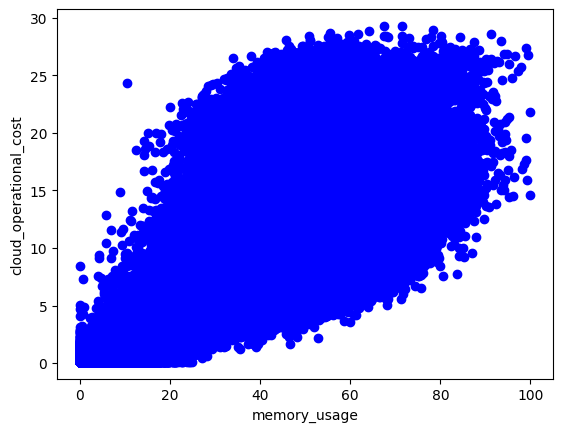

In [225]:
plt.scatter(df["memory_usage"], df["cloud_operational_cost"], color="blue")

plt.xlabel("memory_usage")
plt.ylabel("cloud_operational_cost")

plt.show()

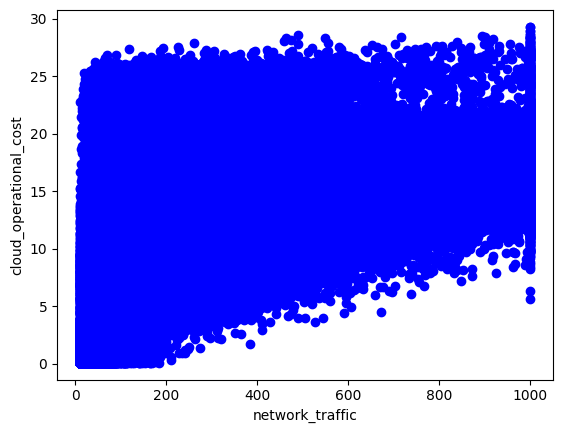

In [226]:
plt.scatter(df["network_traffic"],df["cloud_operational_cost"],color="blue")
plt.xlabel("network_traffic")
plt.ylabel("cloud_operational_cost")
plt.show()

In [227]:
df.corr()

,cpu_usage,memory_usage,network_traffic,execution_time,num_executed_instructions,task_priority,energy_efficiency,cloud_operational_cost
cpu_usage,1.000000,0.760590,0.465318,0.374483,0.740087,0.048627,-0.462107,0.771460
memory_usage,0.760590,1.000000,0.257109,0.378072,0.632092,0.034341,-0.424763,0.676347
network_traffic,0.465318,0.257109,1.000000,0.220507,0.380718,0.001335,-0.196140,0.485833
execution_time,0.374483,0.378072,0.220507,1.000000,0.890957,-0.000586,-0.187947,0.858880
num_executed_instructions,0.740087,0.632092,0.380718,0.890957,1.000000,0.021545,-0.353172,0.984968
task_priority,0.048627,0.034341,0.001335,-0.000586,0.021545,1.000000,-0.023056,0.087210
energy_efficiency,-0.462107,-0.424763,-0.196140,-0.187947,-0.353172,-0.023056,1.000000,-0.403216
cloud_operational_cost,0.771460,0.676347,0.485833,0.858880,0.984968,0.087210,-0.403216,1.000000


In [228]:
corr = df.corr()
corr["cloud_operational_cost"].sort_values(ascending=False)

cloud_operational_cost       1.000000
num_executed_instructions    0.984968
execution_time               0.858880
cpu_usage                    0.771460
memory_usage                 0.676347
network_traffic              0.485833
task_priority                0.087210
energy_efficiency           -0.403216
Name: cloud_operational_cost, dtype: float64

In [229]:
df = df.drop("task_priority", axis=1)

In [230]:
X = df.drop("cloud_operational_cost", axis=1)
Y = df["cloud_operational_cost"]

In [231]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [232]:
print(X_train.shape)
print(X_test.shape)

(160000, 6)
(40000, 6)


In [233]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train, Y_train)
print ('Coefficients: ', regressor.coef_)
print ('Intercept: ',regressor.intercept_)

Coefficients:  [ 0.90034318  0.49481054  0.73356322  1.7497959   2.47009634 -0.22528887]
Intercept:  9.984339892500001


In [234]:
Y_pred = regressor.predict(X_test)

In [235]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


print("mean absolute error:",mean_absolute_error(Y_test, Y_pred))
print("mean squared error:",mean_squared_error(Y_test, Y_pred))  
print("root mean squared error:",np.sqrt(mean_squared_error(Y_test, Y_pred))) 
print("r2 score:",r2_score(Y_test, Y_pred))

mean absolute error: 0.3663581961503876
mean squared error: 0.20245576515253041
root mean squared error: 0.4499508474850674
r2 score: 0.99325055176043


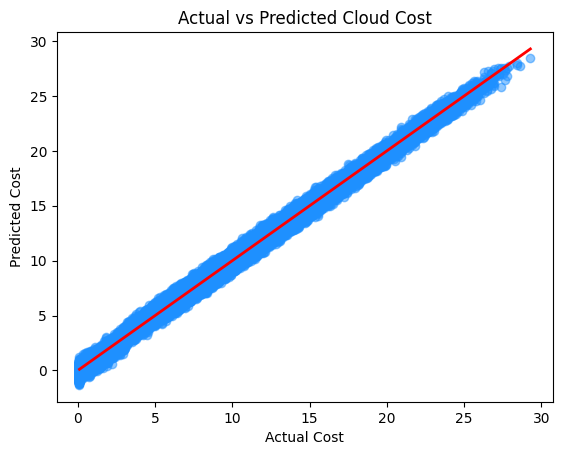

In [236]:
plt.scatter(Y_test, Y_pred, color="dodgerblue", alpha=0.5)

plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color="red", linewidth=2)

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cloud Cost")

plt.show()

In [237]:
import pickle

pickle.dump(regressor, open("../model/cloud_cost_model.pkl", "wb"))

In [238]:
model = pickle.load(open("../model/cloud_cost_model.pkl", "rb"))